# Akshar — Data Preparation (Step-by-Step)

Builds lightweight path-reference JSONL index files (~10 MB) from the on-disk IHTR data.  
The old pipeline embedded every image as base64 in the JSONL (65 GB train + 6.5 GB val). This version just stores file paths.

**Data layout on disk:**
```
data/indic_hw/
  train/<script>/train.txt + train/   (783k images across 10 scripts)
  validation/validationset/<script>/val.txt + val/   (1000/script = 10k curated)
```

**Output:**
```
data/train_index.jsonl   (~10 MB, path references)
data/val_index.jsonl     (~1 MB, uses real validation set)
data/stats.json
```

## 0. Config

In [1]:
import os, json
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display

# ── Paths ──
DATA_DIR   = Path("./data/indic_hw")
OUTPUT_DIR = Path("./data")

# ── Script name -> on-disk folder name ──
IHTR_LOCAL_MAP = {
    "Hindi":      "devanagari",
    "Bengali":    "bengali",
    "Gujarati":   "gujarati",
    "Gurumukhi":  "gurumukhi",
    "Kannada":    "kannada",
    "Malayalam":  "malayalam",
    "Odia":       "odia",
    "Tamil":      "tamil",
    "Telugu":     "telugu",
    "Urdu":       "urdu",
}

SCRIPTS = list(IHTR_LOCAL_MAP.keys())

# ── Quality thresholds ──
MIN_WIDTH  = 20
MIN_HEIGHT = 20
MIN_AREA   = 800
MAX_ASPECT = 15.0

# ── Cap per script (set to None for ALL samples) ──
MAX_PER_SCRIPT = None   # e.g. 20000 for medium run, 100 for smoke test

print(f"Data root  : {DATA_DIR.resolve()}")
print(f"Output dir : {OUTPUT_DIR.resolve()}")
print(f"Scripts    : {SCRIPTS}")
print(f"Cap/script : {MAX_PER_SCRIPT or 'unlimited'}")

Data root  : E:\akshar_benchmark\data\indic_hw
Output dir : E:\akshar_benchmark\data
Scripts    : ['Hindi', 'Bengali', 'Gujarati', 'Gurumukhi', 'Kannada', 'Malayalam', 'Odia', 'Tamil', 'Telugu', 'Urdu']
Cap/script : unlimited


## 1. Verify folder structure

Confirm all 10 scripts have their expected `train.txt` and `val.txt` files.

In [2]:
print(f"{'Script':<12}  {'Train.txt':<10}  {'Train dir':<10}  {'Val.txt':<10}  {'Val dir':<10}  Train lines  Val lines")
print("─" * 95)

for script, folder in IHTR_LOCAL_MAP.items():
    train_txt = DATA_DIR / "train" / folder / "train.txt"
    train_dir = DATA_DIR / "train" / folder / "train"
    val_txt   = DATA_DIR / "validation" / "validationset" / folder / "val.txt"
    val_dir   = DATA_DIR / "validation" / "validationset" / folder / "val"

    train_lines = sum(1 for l in open(train_txt, encoding="utf-8") if l.strip()) if train_txt.exists() else 0
    val_lines   = sum(1 for l in open(val_txt, encoding="utf-8") if l.strip()) if val_txt.exists() else 0

    print(f"{script:<12}  {'OK' if train_txt.exists() else 'MISSING':<10}  "
          f"{'OK' if train_dir.exists() else 'MISSING':<10}  "
          f"{'OK' if val_txt.exists() else 'MISSING':<10}  "
          f"{'OK' if val_dir.exists() else 'MISSING':<10}  "
          f"{train_lines:>11,}  {val_lines:>9,}")

Script        Train.txt   Train dir   Val.txt     Val dir     Train lines  Val lines
───────────────────────────────────────────────────────────────────────────────────────────────
Hindi         OK          OK          OK          OK               69,853      1,000
Bengali       OK          OK          OK          OK               82,554      1,000
Gujarati      OK          OK          OK          OK               82,563      1,000
Gurumukhi     OK          OK          OK          OK               81,042      1,000
Kannada       OK          OK          OK          OK               73,517      1,000
Malayalam     OK          OK          OK          OK               85,270      1,000
Odia          OK          OK          OK          OK               73,400      1,000
Tamil         OK          OK          OK          OK               75,736      1,000
Telugu        OK          OK          OK          OK               80,637      1,000
Urdu          OK          OK          OK          OK  

## 2. Peek at raw label files

Show the first 5 lines of a training `train.txt` and a validation `val.txt` to confirm the format.

In [3]:
# ── Training label file ──
sample_script = "Hindi"
sample_folder = IHTR_LOCAL_MAP[sample_script]
train_txt = DATA_DIR / "train" / sample_folder / "train.txt"

print(f"=== {train_txt} (first 5 lines) ===")
with open(train_txt, encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"  [{i}] {line.rstrip()!r}")

# ── Validation label file ──
val_txt = DATA_DIR / "validation" / "validationset" / sample_folder / "val.txt"

print(f"\n=== {val_txt} (first 5 lines) ===")
with open(val_txt, encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(f"  [{i}] {line.rstrip()!r}")

print("\nExpected format: '<relative_path> <label>' (space-separated)")
print("Val.txt may use 'test/0.jpg' prefix — we remap test/ -> val/")

=== data\indic_hw\train\devanagari\train.txt (first 5 lines) ===
  [0] 'train/8/251/21.jpg केंद्रों'
  [1] 'train/10/207/8.jpg पॉवर'
  [2] 'train/10/31/19.jpg तरक्की'
  [3] 'train/5/246/23.jpg मजा'
  [4] 'train/8/266/25.jpg मांजने'

=== data\indic_hw\validation\validationset\devanagari\val.txt (first 5 lines) ===
  [0] 'test/0.jpg उद्देश्य'
  [1] 'test/1.jpg गणना'
  [2] 'test/2.jpg समस्त'
  [3] 'test/3.jpg कर'
  [4] 'test/4.jpg सकने'

Expected format: '<relative_path> <label>' (space-separated)
Val.txt may use 'test/0.jpg' prefix — we remap test/ -> val/


## 3. Peek at images

Load and display a few training + validation images with their labels.


  TRAIN samples

  [Telugu]  label = "అల్సర్లులాంటి"
  path  = data\indic_hw\train\telugu\train\3\67\11.jpg
  exists = True
  size  = (1632, 297)


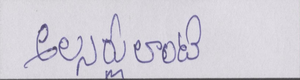


  [Gujarati]  label = "મેચમાં"
  path  = data\indic_hw\train\gujarati\train\30.jpg
  exists = True
  size  = (857, 296)


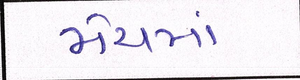


  VAL samples

  [Malayalam]  label = "പിശാച്"
  path  = data\indic_hw\validation\validationset\malayalam\val\12.jpg
  exists = True
  size  = (434, 138)


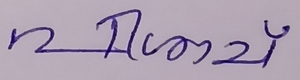


  [Hindi]  label = "सकने"
  path  = data\indic_hw\validation\validationset\devanagari\val\4.jpg
  exists = True
  size  = (168, 82)


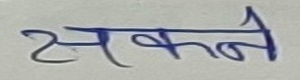

In [4]:
import random

def parse_label_line(line: str):
    """Parse a label line: '<rel_path> <label>' -> (rel_path, label)"""
    parts = line.strip().split(" ", 1)
    if len(parts) == 2:
        return parts[0], parts[1].strip()
    return None, None

# Show 2 training + 2 validation images
for split_name, base_dir, label_name in [
    ("TRAIN", DATA_DIR / "train", "train.txt"),
    ("VAL",   DATA_DIR / "validation" / "validationset", "val.txt"),
]:
    print(f"\n{'='*50}")
    print(f"  {split_name} samples")
    print(f"{'='*50}")

    for script in random.sample(SCRIPTS, 2):
        folder = IHTR_LOCAL_MAP[script]
        script_dir = base_dir / folder
        label_file = script_dir / label_name

        if not label_file.exists():
            print(f"  [{script}] Label file missing: {label_file}")
            continue

        with open(label_file, encoding="utf-8") as f:
            lines = [l for l in f if l.strip()]

        # Pick a random line
        line = random.choice(lines[:100])
        rel_path, label = parse_label_line(line)
        if not rel_path:
            continue

        # Fix val path: test/ -> val/
        if rel_path.startswith("test/"):
            rel_path = "val/" + rel_path[len("test/"):]

        img_path = script_dir / rel_path
        if not img_path.exists():
            img_path = script_dir / "val" / Path(rel_path).name

        print(f"\n  [{script}]  label = \"{label}\"")
        print(f"  path  = {img_path}")
        print(f"  exists = {img_path.exists()}")

        if img_path.exists():
            img = Image.open(img_path).convert("RGB")
            print(f"  size  = {img.size}")
            display(img.resize((300, 80), Image.LANCZOS))

## 4. Define quality filter + loaders

Same functions used by `dataset_prep.py`. Defined here so you can test them.

In [5]:
from typing import Optional, Iterator

def passes_quality_filter(img: Image.Image) -> bool:
    w, h = img.size
    if w < MIN_WIDTH or h < MIN_HEIGHT:
        return False
    if w * h < MIN_AREA:
        return False
    if h > 0 and (w / h) > MAX_ASPECT:
        return False
    return True


def load_train_local(script: str, max_samples: Optional[int] = None) -> Iterator[tuple[str, str]]:
    """Yield (absolute_image_path, label) from training split."""
    folder = IHTR_LOCAL_MAP[script]
    script_dir = DATA_DIR / "train" / folder
    label_file = script_dir / "train.txt"

    if not label_file.exists():
        print(f"[ERROR] {label_file} not found")
        return

    filtered = yielded = 0
    with open(label_file, encoding="utf-8") as f:
        for line in f:
            if max_samples and yielded >= max_samples:
                break
            line = line.strip()
            if not line:
                continue
            parts = line.split(" ", 1)
            if len(parts) != 2:
                continue
            rel_path, label = parts
            label = label.strip()
            if not label:
                continue

            img_path = script_dir / rel_path
            if not img_path.exists():
                continue

            try:
                img = Image.open(img_path)
                img.load()
                if not passes_quality_filter(img):
                    filtered += 1
                    continue
                del img
            except Exception:
                continue

            yielded += 1
            yield str(img_path.resolve()), label

    if filtered:
        print(f"  [{script}] Filtered {filtered} low-quality images")


def load_val_local(script: str, max_samples: Optional[int] = None) -> Iterator[tuple[str, str]]:
    """Yield (absolute_image_path, label) from curated validation split."""
    folder = IHTR_LOCAL_MAP[script]
    val_dir    = DATA_DIR / "validation" / "validationset" / folder
    label_file = val_dir / "val.txt"

    if not label_file.exists():
        print(f"  [{script}] No val.txt at {label_file}")
        return

    yielded = 0
    with open(label_file, encoding="utf-8") as f:
        for line in f:
            if max_samples and yielded >= max_samples:
                break
            line = line.strip()
            if not line:
                continue
            parts = line.split(" ", 1)
            if len(parts) != 2:
                continue
            rel_path, label = parts
            label = label.strip()
            if not label:
                continue

            # Fix: val.txt says "test/0.jpg" but images are in "val/"
            if rel_path.startswith("test/"):
                rel_path = "val/" + rel_path[len("test/"):]

            img_path = val_dir / rel_path
            if not img_path.exists():
                img_path = val_dir / "val" / Path(rel_path).name
            if not img_path.exists():
                continue

            yielded += 1
            yield str(img_path.resolve()), label


print("Quality filter + loaders defined.")

Quality filter + loaders defined.


## 5. Test loaders on one script

Quick sanity: load 10 train + 5 val samples from one script, confirm paths resolve and quality filter works.

In [6]:
test_script = "Kannada"

print(f"── Train loader ({test_script}, 10 samples) ──")
for i, (path, label) in enumerate(load_train_local(test_script, max_samples=10)):
    exists = os.path.exists(path)
    print(f"  {i:2d}: label=\"{label}\"  exists={exists}  path=.../{Path(path).name}")

print(f"\n── Val loader ({test_script}, 5 samples) ──")
for i, (path, label) in enumerate(load_val_local(test_script, max_samples=5)):
    exists = os.path.exists(path)
    print(f"  {i:2d}: label=\"{label}\"  exists={exists}  path=.../{Path(path).name}")

print("\nIf all show exists=True, the loaders are working correctly.")

── Train loader (Kannada, 10 samples) ──
   0: label="ನಾಜೂಕಾಗಿರುವುದರಿಂದ"  exists=True  path=.../1.jpg
   1: label="ಗುರುತಿಸಿಕೊಂಡಮೇಲೆ"  exists=True  path=.../2.jpg
   2: label="ವರಿಷ್ಠ"  exists=True  path=.../3.jpg
   3: label="ಪ್ರಾರ್ಥಿಸಿದ"  exists=True  path=.../4.jpg
   4: label="ಮೊರೆಹೋಗಿದ್ದಾರೆ"  exists=True  path=.../5.jpg
   5: label="೭೫೦೦೦"  exists=True  path=.../6.jpg
   6: label="ಅಂಗವಿಕಲರಿಗೂ"  exists=True  path=.../7.jpg
   7: label="ಸೂಚ್ಯಂಕವು"  exists=True  path=.../8.jpg
   8: label="ಐಜಿ"  exists=True  path=.../9.jpg
   9: label="ಕೈಬಿಡಬೇಕೆಂದು"  exists=True  path=.../10.jpg

── Val loader (Kannada, 5 samples) ──
   0: label="ಹಾನಿರಹಿತವಾದ"  exists=True  path=.../0.jpg
   1: label="ಸಂಭವಿಸಿವೆ"  exists=True  path=.../1.jpg
   2: label="ಅನ್ನು"  exists=True  path=.../2.jpg
   3: label="ಹೇಳಿದೆ"  exists=True  path=.../3.jpg
   4: label="ಪ್ರಮುಖ"  exists=True  path=.../4.jpg

If all show exists=True, the loaders are working correctly.


## 6. Build index JSONL files

This is the main step. Creates:
- `data/train_index.jsonl` — one JSON line per training image (just path + label + script)
- `data/val_index.jsonl` — one JSON line per validation image (curated set, not split from train)

Should take **minutes, not hours** since we're just writing paths, not encoding images.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
train_out = OUTPUT_DIR / "train_index.jsonl"
val_out   = OUTPUT_DIR / "val_index.jsonl"
stats     = {}

with open(train_out, "w", encoding="utf-8") as f_train, \
     open(val_out,   "w", encoding="utf-8") as f_val:

    for script in SCRIPTS:
        print(f"\n{'='*55}")
        print(f"  {script}")
        print(f"{'='*55}")

        # ── Training ──
        train_count = 0
        for img_path, label in tqdm(load_train_local(script, MAX_PER_SCRIPT), desc=f"{script} train", unit="img"):
            record = {"script": script, "label": label, "image_path": img_path}
            f_train.write(json.dumps(record, ensure_ascii=False) + "\n")
            train_count += 1

        # ── Validation (curated on-disk set) ──
        val_count = 0
        for img_path, label in tqdm(load_val_local(script), desc=f"{script} val", unit="img"):
            record = {"script": script, "label": label, "image_path": img_path}
            f_val.write(json.dumps(record, ensure_ascii=False) + "\n")
            val_count += 1

        stats[script] = {"train": train_count, "val": val_count}
        print(f"  => {train_count:,} train | {val_count:,} val")

# Save stats
with open(OUTPUT_DIR / "stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print(f"\n{'='*55}")
print(f"Done!")


  Hindi


Hindi train: 0img [00:00, ?img/s]

Hindi val: 0img [00:00, ?img/s]

  => 69,853 train | 1,000 val

  Bengali


Bengali train: 0img [00:00, ?img/s]

...

Telugu val: 0img [00:00, ?img/s]

  => 80,637 train | 1,000 val

  Urdu


Urdu train: 0img [00:00, ?img/s]

Urdu val: 0img [00:00, ?img/s]

  => 71,207 train | 1,000 val

Done!


## 7. Verify outputs

Check file sizes, record counts, and peek at a few lines.

In [8]:
# ── File sizes ──
for name, path in [("train_index.jsonl", train_out), ("val_index.jsonl", val_out)]:
    if path.exists():
        size_mb = path.stat().st_size / 1024 / 1024
        n_lines = sum(1 for _ in open(path, encoding="utf-8"))
        print(f"{name:25s}  {size_mb:8.1f} MB  {n_lines:>10,} records")
    else:
        print(f"{name:25s}  MISSING")

# Compare to legacy
for name in ["train.jsonl", "val.jsonl"]:
    p = OUTPUT_DIR / name
    if p.exists():
        size_gb = p.stat().st_size / 1024**3
        print(f"{name:25s}  {size_gb:8.1f} GB  (legacy base64 — can be deleted)")

# ── Stats summary ──
print(f"\n{'Script':<12}  {'Train':>8}  {'Val':>6}")
print("─" * 30)
total_t = total_v = 0
for script, counts in stats.items():
    print(f"{script:<12}  {counts['train']:>8,}  {counts['val']:>6,}")
    total_t += counts["train"]
    total_v += counts["val"]
print("─" * 30)
print(f"{'TOTAL':<12}  {total_t:>8,}  {total_v:>6,}")

train_index.jsonl             108.7 MB     775,650 records
val_index.jsonl                 1.5 MB      10,000 records
train.jsonl                    60.6 GB  (legacy base64 — can be deleted)
val.jsonl                       6.1 GB  (legacy base64 — can be deleted)

Script           Train     Val
──────────────────────────────
Hindi           69,853   1,000
Bengali         82,554   1,000
Gujarati        82,563   1,000
Gurumukhi       81,042   1,000
Kannada         73,517   1,000
Malayalam       85,163   1,000
Odia            73,400   1,000
Tamil           75,714   1,000
Telugu          80,637   1,000
Urdu            71,207   1,000
──────────────────────────────
TOTAL          775,650  10,000


## 8. Peek at generated JSONL records

In [9]:
print("── First 3 train records ──")
with open(train_out, encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        rec = json.loads(line)
        print(f"  script={rec['script']:<12}  label=\"{rec['label']}\"")
        print(f"  image_path=.../{Path(rec['image_path']).name}")
        print(f"  file exists={os.path.exists(rec['image_path'])}")
        print()

print("── First 3 val records ──")
with open(val_out, encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        rec = json.loads(line)
        print(f"  script={rec['script']:<12}  label=\"{rec['label']}\"")
        print(f"  image_path=.../{Path(rec['image_path']).name}")
        print(f"  file exists={os.path.exists(rec['image_path'])}")
        print()

── First 3 train records ──
  script=Hindi         label="केंद्रों"
  image_path=.../21.jpg
  file exists=True

  script=Hindi         label="पॉवर"
  image_path=.../8.jpg
  file exists=True

  script=Hindi         label="तरक्की"
  image_path=.../19.jpg
  file exists=True

── First 3 val records ──
  script=Hindi         label="उद्देश्य"
  image_path=.../0.jpg
  file exists=True

  script=Hindi         label="गणना"
  image_path=.../1.jpg
  file exists=True

  script=Hindi         label="समस्त"
  image_path=.../2.jpg
  file exists=True



## 9. End-to-end test: load with AksharDataset

Confirm the training pipeline can read the new index files. This is the same `AksharDataset` used in `finetune.py` / `finetune_notebook.ipynb`.

  Indexed 100 records

Sample 0:
  Role 0     : user
  Content[0] : type=image
  Content[1] : type=text, text="Read the handwritten word in this image and output ONLY the ..."
  Role 1     : assistant
  Label      : "केंद्रों"
  Image size : (587, 293)


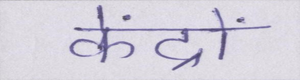

In [10]:
import base64
from io import BytesIO
from torch.utils.data import Dataset as TorchDataset

class AksharDataset(TorchDataset):
    """Same as finetune.py — supports path-reference + legacy base64."""

    def __init__(self, jsonl_path, max_samples=None):
        self.jsonl_path = jsonl_path
        self.offsets = []
        with open(jsonl_path, "rb") as f:
            pos = 0
            for raw_line in f:
                if raw_line.strip():
                    self.offsets.append(pos)
                    if max_samples and len(self.offsets) >= max_samples:
                        break
                pos += len(raw_line)
        print(f"  Indexed {len(self.offsets):,} records")

    def __len__(self):
        return len(self.offsets)

    def _read_record(self, idx):
        with open(self.jsonl_path, "rb") as f:
            f.seek(self.offsets[idx])
            return json.loads(f.readline())

    USER_PROMPT = (
        "Read the handwritten word in this image and output ONLY the word "
        "in its original script. Do not add any explanation or translation."
    )

    def __getitem__(self, idx):
        rec = self._read_record(idx)
        if "image_path" in rec:
            img = Image.open(rec["image_path"]).convert("RGB")
            img.load()
        elif "image_b64" in rec:
            img = Image.open(BytesIO(base64.b64decode(rec["image_b64"]))).convert("RGB")
            img.load()
        else:
            raise ValueError(f"Record {idx}: no image_path or image_b64")

        label = rec.get("label", "")
        return {
            "messages": [
                {"role": "user", "content": [
                    {"type": "image", "image": img},
                    {"type": "text", "text": self.USER_PROMPT},
                ]},
                {"role": "assistant", "content": [
                    {"type": "text", "text": label},
                ]},
            ],
        }

# Test it
ds = AksharDataset(str(train_out), max_samples=100)
sample = ds[0]
msgs = sample["messages"]

print(f"\nSample 0:")
print(f"  Role 0     : {msgs[0]['role']}")
print(f"  Content[0] : type={msgs[0]['content'][0]['type']}")
print(f"  Content[1] : type={msgs[0]['content'][1]['type']}, text=\"{msgs[0]['content'][1]['text'][:60]}...\"")
print(f"  Role 1     : {msgs[1]['role']}")
print(f"  Label      : \"{msgs[1]['content'][0]['text']}\"")
print(f"  Image size : {msgs[0]['content'][0]['image'].size}")
display(msgs[0]["content"][0]["image"].resize((300, 80), Image.LANCZOS))

## 10. (Optional) Clean up legacy files

The old 65 GB `train.jsonl` and 6.5 GB `val.jsonl` are no longer needed.  
Uncomment to delete them and reclaim ~72 GB of disk.

In [ ]:
# Uncomment these lines to delete the old base64-embedded JSONL files:

# legacy_train = OUTPUT_DIR / "train.jsonl"
# legacy_val   = OUTPUT_DIR / "val.jsonl"

# if legacy_train.exists():
#     size_gb = legacy_train.stat().st_size / 1024**3
#     legacy_train.unlink()
#     print(f"Deleted train.jsonl ({size_gb:.1f} GB)")

# if legacy_val.exists():
#     size_gb = legacy_val.stat().st_size / 1024**3
#     legacy_val.unlink()
#     print(f"Deleted val.jsonl ({size_gb:.1f} GB)")

print("Legacy files NOT deleted (uncomment above to remove).")

Deleted train.jsonl (60.6 GB)
Deleted val.jsonl (6.1 GB)
Legacy files NOT deleted (uncomment above to remove).


---

## What changed vs the old pipeline

| Before (broken) | After (fixed) |
|-----------------|---------------|
| Every image base64-encoded in JSONL | Path references only (~10 MB vs 65 GB) |
| Validation = last 10% of training data | Real curated val set (10k images from `validation/validationset/`) |
| 20k training samples wasted as val | All training data used for training |
| val.txt `test/0.jpg` path never resolved | Remapped `test/` -> `val/` automatically |
| Hours to generate JSONL | Minutes (no image encoding) |

## Next step

Run **`data_prep_notebook.ipynb`** first, then open **`finetune_notebook.ipynb`** to train.